In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json, os
from games.rps import RPS
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

from utils.experiment import run_experiment, run_experiment_and_plot
from utils.io import save_results
from utils.plotting import plot_with_ci, smooth
from utils.metrics import dist_to_ne
from utils.constants import COLORS


## Rock-Paper-Scissors

Juego de **suma cero** con 2 agentes y 3 acciones: **R** (piedra), **P** (papel) y **S** (tijera).

Matrices de utilidades (filas = `agent_0`, columnas = `agent_1`):

|           | **R**     | **P**     | **S**     |
|-----------|-----------|-----------|-----------|
| **R**     | (0, 0)    | (−1, +1)  | (+1, −1)  |
| **P**     | (+1, −1)  | (0, 0)    | (−1, +1)  |
| **S**     | (−1, +1)  | (+1, −1)  | (0, 0)    |

#

> Cada celda muestra `(u_0, u_1)`. Al ser un juego de suma cero, siempre `u_0 + u_1 = 0`.

**Estrategias dominantes puras:** no existen. Para cualquier acción pura que elija un jugador, el oponente siempre tiene una respuesta estrictamente mejor:
- Si `agent_0` juega R, `agent_1` prefiere P. Si juega P, prefiere S. Si juega S, prefiere R → ciclo sin dominancia.
- Lo mismo aplica simétricamente para `agent_0`.

**Equilibrio de Nash (EN):** la única solución es la **estrategia mixta uniforme** $\pi^* = (1/3,\, 1/3,\, 1/3)$ para ambos jugadores. En el EN, el reward esperado de cada agente es **0**.

In [2]:
N_EPISODES = 20_000
N_SEEDS    = 10
NE_RPS     = np.array([1/3, 1/3, 1/3])
os.makedirs('results/RPS', exist_ok=True)
os.makedirs('figures/RPS', exist_ok=True)

In [3]:
g = RPS()

In [4]:
g.reset()

In [5]:
rm = dict(map(lambda agent: (agent, RegretMatching(game=g, agent=agent, seed=1)), g.agents))

In [6]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, rm[agent].action()), g.agents))
    g.step(actions)

In [7]:
dict(map(lambda agent: (agent, rm[agent].policy()), g.agents))

{'agent_0': array([0.33382656, 0.33902779, 0.32714565]),
 'agent_1': array([0.34451397, 0.31698731, 0.33849871])}

In [8]:
agent_classes = [ RegretMatching, RandomAgent ]
my_agents = {}
g.reset()
for i, agent in enumerate(g.agents):
    my_agents[agent] = agent_classes[i](game=g, agent=agent)


In [9]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, my_agents[agent].action()), g.agents))
    g.step(actions)

In [10]:
dict(map(lambda agent: (agent, my_agents[agent].policy()), g.agents))

{'agent_0': array([0.40212358, 0.39690177, 0.20097466]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

In [11]:
g.reset()

In [12]:
fp = dict(map(lambda agent: (agent, FictitiousPlay(game=g, agent=agent, seed=1)), g.agents))

In [13]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, fp[agent].action()), g.agents))
    g.step(actions)

In [14]:
dict(map(lambda agent: (agent, fp[agent].policy()), g.agents))

{'agent_0': array([0.33512974, 0.32694611, 0.33792415]),
 'agent_1': array([0.32950115, 0.33929821, 0.33120064])}

In [15]:
agent_classes = [ FictitiousPlay, RandomAgent ]
my_agents = {}
g.reset()
for i, agent in enumerate(g.agents):
    my_agents[agent] = agent_classes[i](game=g, agent=agent)


In [16]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, my_agents[agent].action()), g.agents))
    g.step(actions)

In [17]:
dict(map(lambda agent: (agent, my_agents[agent].policy()), g.agents))

{'agent_0': array([0.18836095, 0.00329407, 0.80834498]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

In [18]:
g.reset()
iql = dict(map(lambda agent: (agent, IndependentQLearning(game=g, agent=agent, seed=1)), g.agents))

In [19]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, iql[agent].action()), g.agents))
    g.step(actions)

In [20]:
dict(map(lambda agent: (agent, iql[agent].policy()), g.agents))

{'agent_0': array([0.33333333, 0.33333333, 0.33333333]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

In [21]:
agent_classes = [ IndependentQLearning, RandomAgent ]
my_agents = {}
g.reset()
for i, agent in enumerate(g.agents):
    my_agents[agent] = agent_classes[i](game=g, agent=agent)

In [22]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, my_agents[agent].action()), g.agents))
    g.step(actions)

In [23]:
dict(map(lambda agent: (agent, my_agents[agent].policy()), g.agents))

{'agent_0': array([0.26069218, 0.46914625, 0.27016156]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

#### SECCIÓN 1 — Experimento: FP vs FP


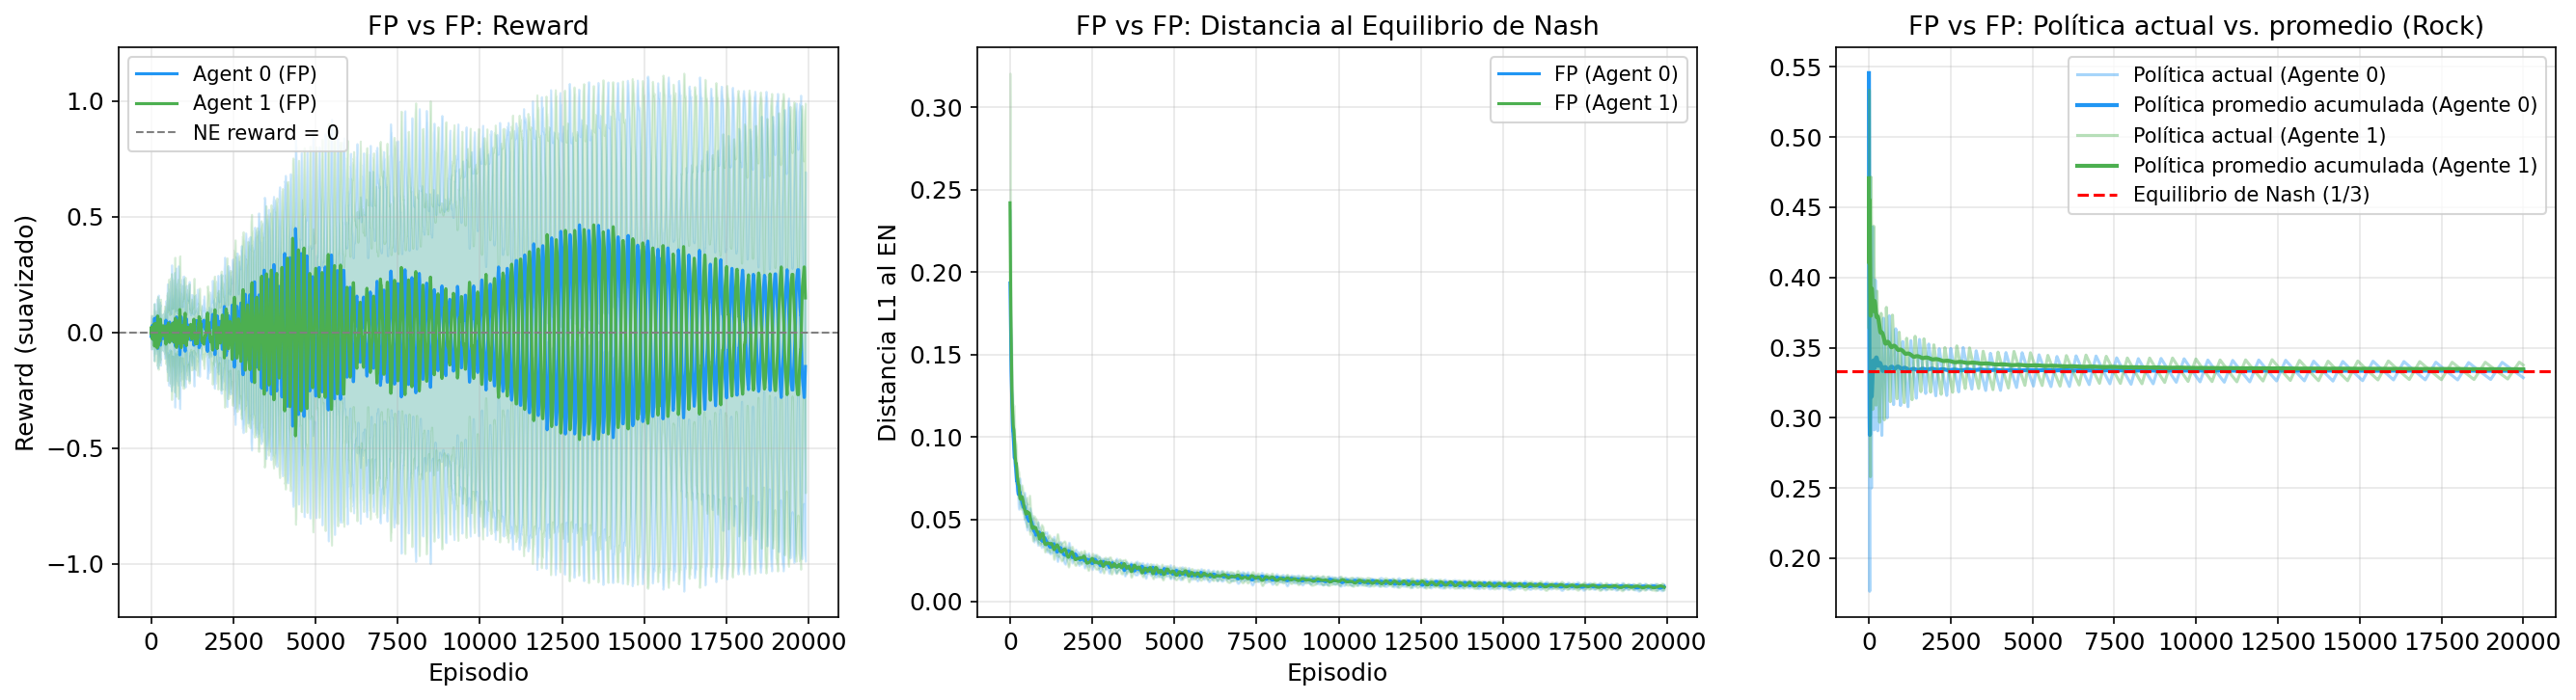

<Figure size 1350x750 with 0 Axes>

Política final FP (promedio sobre seeds):
  Agent 0: [0.331 0.334 0.335]
  Agent 1: [0.335 0.333 0.331]
  Equilibrio de Nash: [0.333 0.333 0.333]


In [ ]:
# Gráfica 1a: Reward promedio
rewards_fp, pol0_fp, pol1_fp = run_experiment(
    RPS, FictitiousPlay, FictitiousPlay, N_EPISODES, N_SEEDS)

save_results('RPS', 'FP_vs_FP', rewards_fp, pol0_fp, pol1_fp,
             ne=NE_RPS.tolist(), hyperparams={'n_episodes': N_EPISODES})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_with_ci(rewards_fp[:, :, 0], 'Agent 0 (FP)', COLORS['FP'], ax=axes[0])
plot_with_ci(rewards_fp[:, :, 1], 'Agent 1 (FP)', COLORS['RM'], ax=axes[0])
axes[0].axhline(0, ls='--', c='gray', lw=1, label='NE reward = 0')
axes[0].set_xlabel('Episodio'); axes[0].set_ylabel('Reward (suavizado)')
axes[0].set_title('FP vs FP: Reward'); axes[0].legend()

# Gráfica 1b: Distancia al Equilibrio de Nash
d_fp0 = dist_to_ne(pol0_fp, NE_RPS)
d_fp1 = dist_to_ne(pol1_fp, NE_RPS)
plot_with_ci(d_fp0, 'FP (Agent 0)', COLORS['FP'], ax=axes[1])
plot_with_ci(d_fp1, 'FP (Agent 1)', COLORS['RM'], ax=axes[1])
axes[1].set_xlabel('Episodio'); axes[1].set_ylabel('Distancia L1 al EN')
axes[1].set_title('FP vs FP: Distancia al Equilibrio de Nash'); axes[1].legend()



# Política actual vs. promedio (seed 0, acción Rock)
pol_curr = pol0_fp[0, :, 0]                     # política actual, acción Rock, seed 0
pol_avg  = np.cumsum(pol0_fp[0, :, 0]) / (np.arange(N_EPISODES) + 1)  # promedio acumulado
axes[2].plot(pol_curr, alpha=0.4, color=COLORS['FP'], label='Política actual (Agente 0)')
axes[2].plot(pol_avg,  color=COLORS['FP'], lw=2, label='Política promedio acumulada (Agente 0)')

pol1_curr = pol1_fp[0, :, 0]                     # política actual, acción Rock, seed 0
pol1_avg  = np.cumsum(pol1_fp[0, :, 0]) / (np.arange(N_EPISODES) + 1)  # promedio acumulado
axes[2].plot(pol1_curr, alpha=0.4, color=COLORS['RM'], label='Política actual (Agente 1)')
axes[2].plot(pol1_avg,  color=COLORS['RM'], lw=2, label='Política promedio acumulada (Agente 1)')

axes[2].axhline(1/3, ls='--', c='red', label='Equilibrio de Nash (1/3)')
axes[2].set_title('FP vs FP: Política actual vs. promedio (Rock)'); axes[2].legend()
plt.tight_layout(); plt.savefig('figures/RPS/rm_vs_rm.png', dpi=150); plt.show()

plt.tight_layout()
plt.savefig('figures/RPS/fp_vs_fp.png', dpi=150)
plt.show()

# Política final
print("Política final FP (promedio sobre seeds):")
print(f"  Agent 0: {pol0_fp[:, -100:, :].mean(axis=(0,1)).round(3)}")
print(f"  Agent 1: {pol1_fp[:, -100:, :].mean(axis=(0,1)).round(3)}")
print(f"  Equilibrio de Nash: {NE_RPS.round(3)}")


## Observaciones

Podemos ver como las recompesas de ambos agentes oscilaron alrededor de cero durante todo el entrenamiento, lo cual tiene sentido dado que se trata de un juego zero-sum donde ninguno de los jugadores puede mantener una ventaja permanente sobre el otro.

Sin embargo, aunque las estrategias instantáneas no convergen de forma estable, puede verse que la distancia al equilibrio de Nash disminuye progresivamente a medida que avanzan los episodios. De la misma forma, las políticas promedio acumuladas convergen hacia una distribución cercana a $1/3$ para cada acción, que corresponde al equilibrio mixto esperado en Rock-Paper-Scissors.

En conjunto, los experimentos muestran que Fictitious Play no converge necesariamente en las políticas instantáneas, pero mirando en la politica promedio (tercer grafico) podemos ver como sí logra aproximar correctamente el equilibrio de Nash.

#### SECCIÓN 2 — Experimento: RM vs RM
**Hipótesis:** RM converge al NE (garantía teórica de no-regret). La política PROMEDIO converge; la actual oscila.

Saved → results/RPS/RM_vs_RM/results.json


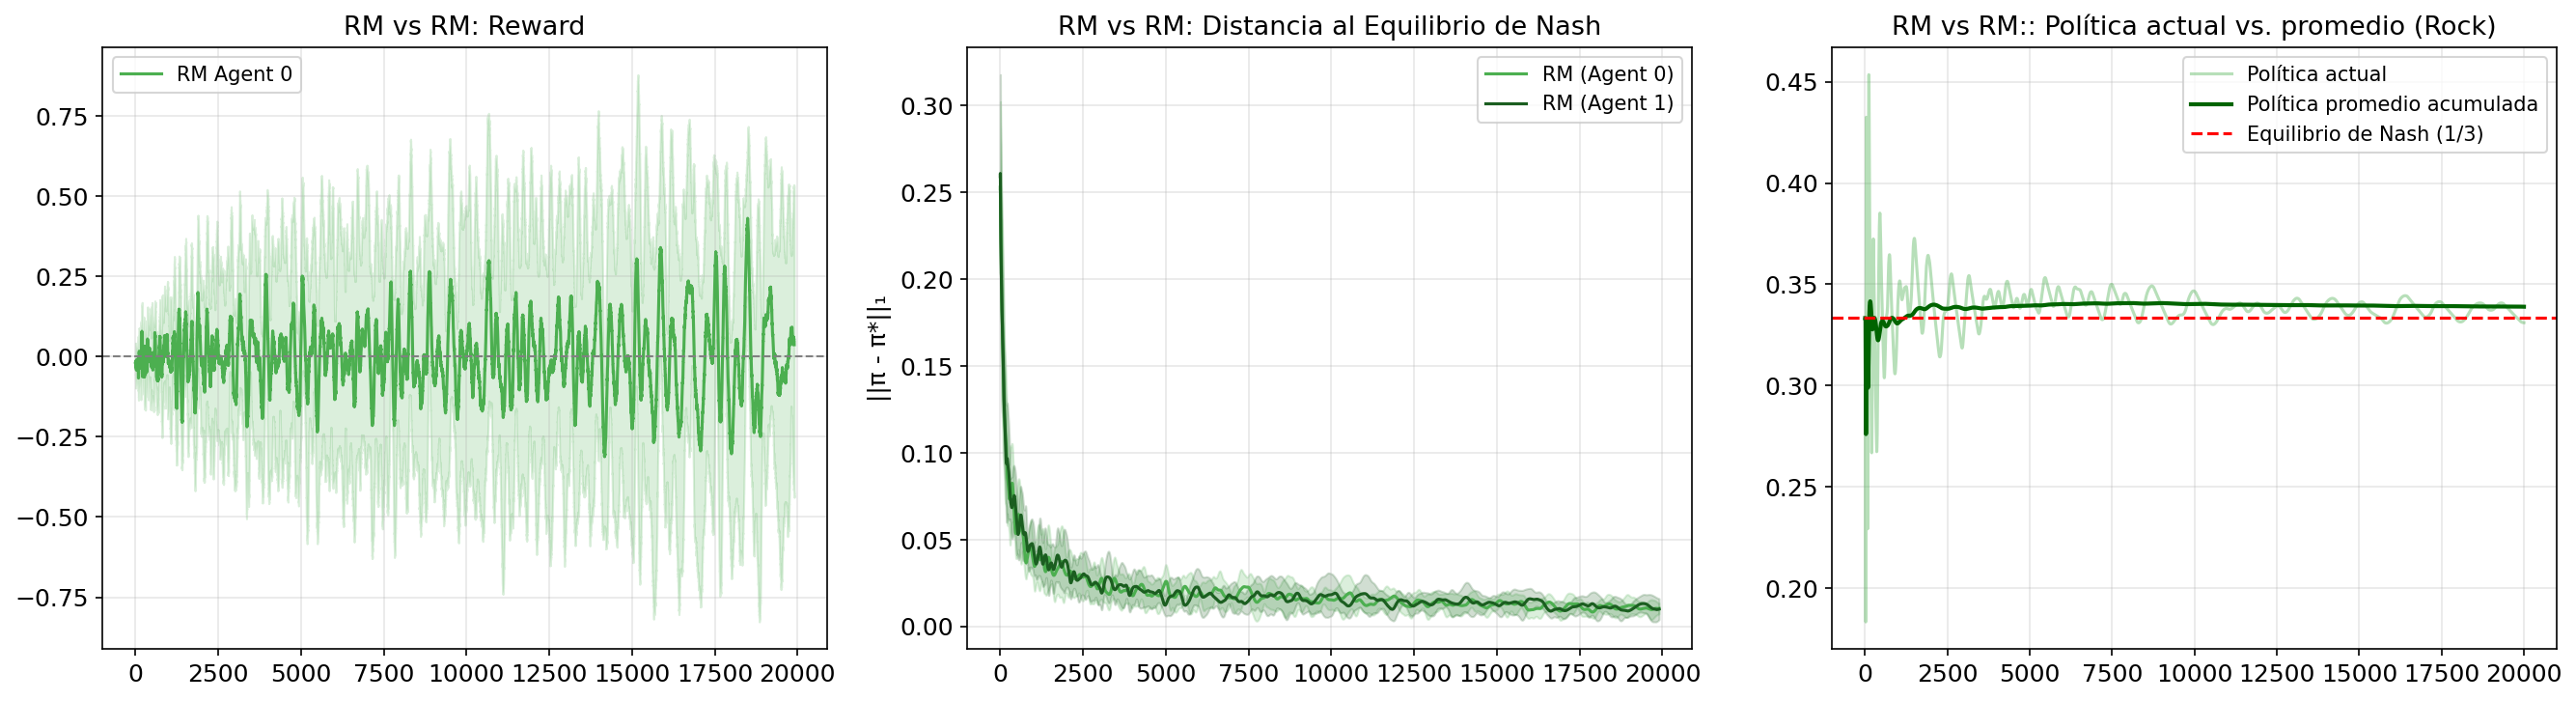

In [26]:
# --- RPS-2: RM vs RM ---
rewards_rm, pol0_rm, pol1_rm = run_experiment(
    RPS, RegretMatching, RegretMatching, N_EPISODES, N_SEEDS)

save_results('RPS', 'RM_vs_RM', rewards_rm, pol0_rm, pol1_rm, ne=NE_RPS.tolist())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reward
plot_with_ci(rewards_rm[:, :, 0], 'RM Agent 0', COLORS['RM'], ax=axes[0])
axes[0].axhline(0, ls='--', c='gray', lw=1); axes[0].set_title('RM vs RM: Reward'); axes[0].legend()

# Distancia al Equilibrio de Nash
d_rm0 = dist_to_ne(pol0_rm, NE_RPS)
d_rm1 = dist_to_ne(pol1_rm, NE_RPS)
plot_with_ci(d_rm0, 'RM (Agent 0)', COLORS['RM'], ax=axes[1])
plot_with_ci(d_rm1, 'RM (Agent 1)', '#1B5E20', ax=axes[1])
axes[1].set_title('RM vs RM: Distancia al Equilibrio de Nash'); axes[1].set_ylabel('||\u03c0 - \u03c0*||\u2081'); axes[1].legend()

# Política actual vs. promedio (seed 0, acción Rock)
pol_curr = pol0_rm[0, :, 0]                     # política actual, acción Rock, seed 0
pol_avg  = np.cumsum(pol0_rm[0, :, 0]) / (np.arange(N_EPISODES) + 1)  # promedio acumulado
axes[2].plot(pol_curr, alpha=0.4, color=COLORS['RM'], label='Política actual')
axes[2].plot(pol_avg,  color='darkgreen', lw=2, label='Política promedio acumulada')
axes[2].axhline(1/3, ls='--', c='red', label='Equilibrio de Nash (1/3)')
axes[2].set_title('RM vs RM:: Política actual vs. promedio (Rock)'); axes[2].legend()
plt.tight_layout(); plt.savefig('figures/RPS/rm_vs_rm.png', dpi=150); plt.show()


## Observación

En general, los resultados obtenidos muestran un comportamiento consistente con lo esperado teóricamente para Regret Matching en Rock-Paper-Scissors.

Las recompensas de ambos agentes oscilaron alrededor de cero durante todo el entrenamiento, lo cual resulta esperable en un juego zero-sum donde ninguno de los jugadores puede mantener una ventaja permanente sobre el otro. A diferencia de FP, las oscilaciones observadas en RM parecen más pequeñas y estables a medida que avanza el entrenamiento.

Además, puede observarse que la distancia al equilibrio de Nash disminuye rápidamente durante los primeros episodios y luego converge hacia valores muy cercanos a cero. Esto indica que las estrategias aprendidas se aproximan progresivamente al equilibrio mixto esperado del juego.

Por otro lado, la política promedio acumulada converge de manera bastante estable hacia una probabilidad cercana a $1/3$. Aunque la política continúa presentando pequeñas oscilaciones, estas se reducen con el tiempo y permanecen cerca del equilibrio.

En conjunto, los resultados muestran que Regret Matching logra aproximar correctamente el equilibrio de Nash y presenta un comportamiento estable durante el entrenamiento, consistente con las propiedades teóricas de no-regret learning.

#### SECCIÓN 3 — Experimento RPS-3: IQL vs IQL
**Hipótesis:** IQL puede ciclar (R→P→S→R) por non-stationarity.


In [27]:
iql_kwargs = dict(alpha=0.1, gamma=0.0, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01)

Saved → results/RPS/IQL_vs_IQL/results.json


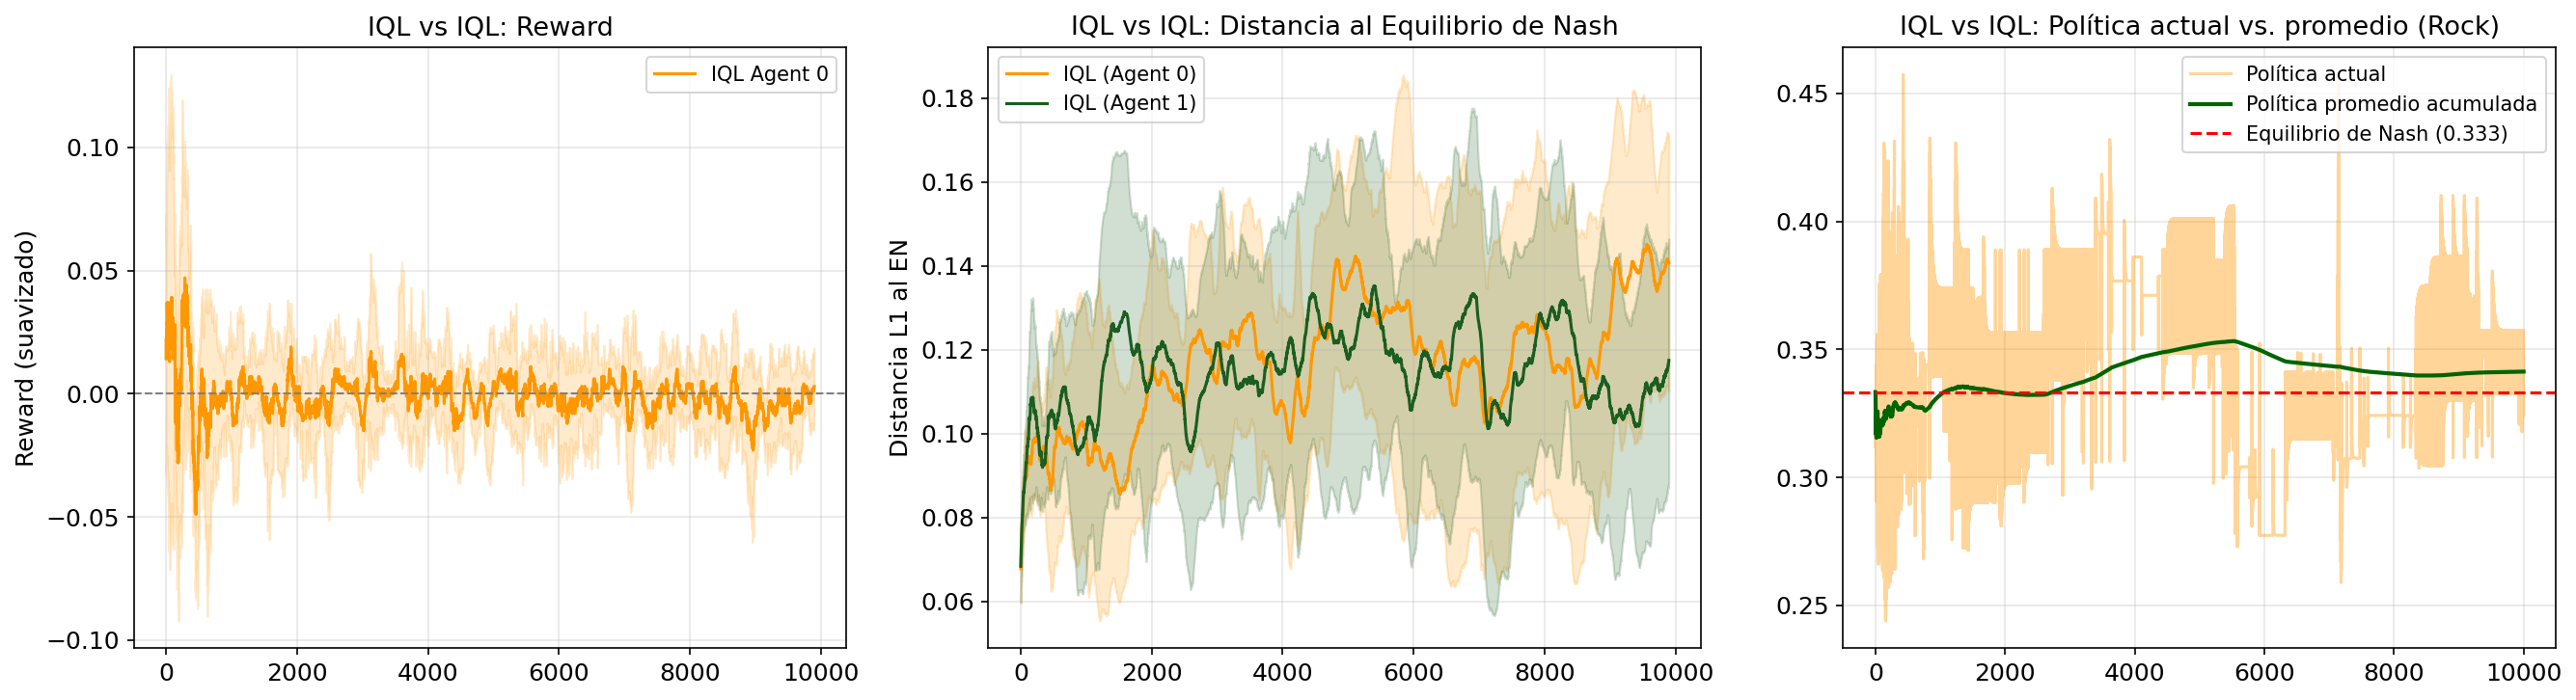

Política final FP (promedio sobre seeds):
  Agent 0: [0.323 0.342 0.335]
  Agent 1: [0.338 0.337 0.325]
  Equilibrio de Nash: [0.333 0.333 0.333]


(array([[[ 1., -1.],
         [-1.,  1.],
         [-1.,  1.],
         ...,
         [ 1., -1.],
         [ 0., -0.],
         [ 0., -0.]],
 
        [[ 0., -0.],
         [ 1., -1.],
         [-1.,  1.],
         ...,
         [ 0., -0.],
         [ 0., -0.],
         [ 0., -0.]],
 
        [[-1.,  1.],
         [-1.,  1.],
         [ 1., -1.],
         ...,
         [ 0., -0.],
         [ 0., -0.],
         [ 0., -0.]],
 
        ...,
 
        [[ 0., -0.],
         [ 1., -1.],
         [-1.,  1.],
         ...,
         [ 0., -0.],
         [ 0., -0.],
         [ 0., -0.]],
 
        [[ 1., -1.],
         [ 1., -1.],
         [-1.,  1.],
         ...,
         [ 0., -0.],
         [ 0., -0.],
         [ 0., -0.]],
 
        [[-1.,  1.],
         [ 1., -1.],
         [ 1., -1.],
         ...,
         [ 0., -0.],
         [ 0., -0.],
         [ 0., -0.]]], shape=(10, 10000, 2)),
 array([[[0.33333333, 0.33333333, 0.33333333],
         [0.33333333, 0.33333333, 0.33333333],
         [0

In [28]:
run_experiment_and_plot(
    RPS, IndependentQLearning, IndependentQLearning,
    NE=NE_RPS, color=COLORS['IQL'],
    game_name='RPS', experiment_name='IQL_vs_IQL',
    agent0_label='IQL', agent1_label='IQL',
    agent0_kwargs=iql_kwargs, agent1_kwargs=iql_kwargs
)

### Observaciones

En general, los resultados obtenidos muestran que Independent Q-Learning presenta un comportamiento mucho más inestable que FP y RM en Rock-Paper-Scissors.

Las recompensas de ambos agentes permanecen oscilando alrededor de cero durante todo el entrenamiento, lo cual resulta esperable en un juego zero-sum. Sin embargo, a diferencia de FP y RM, las oscilaciones parecen más ruidosas y menos estables, reflejando la dificultad de aprendizaje causada por la no estacionariedad del entorno.

Además, la distancia al equilibrio de Nash no muestra una convergencia clara hacia cero. Aunque las políticas aprendidas se mantienen relativamente cerca del equilibrio mixto esperado, las fluctuaciones persisten durante todo el entrenamiento. Esto sugiere que los agentes continúan adaptándose constantemente a los cambios en la política del oponente.

Por otro lado, la política promedio acumulada logra acercarse a la distribución uniforme esperada de $1/3$. Sin embargo, la política instantánea presenta variaciones importantes y no converge de manera estable.

En conjunto, los resultados muestran que IQL puede aproximar parcialmente el equilibrio de Nash en promedio, pero presenta mayores problemas de estabilidad y convergencia que FP y RM. Esto resulta consistente con la principal limitación de Independent Q-Learning en ambientes multiagente: cada agente aprende asumiendo que el entorno es estacionario, cuando en realidad las políticas de los demás agentes cambian continuamente durante el entrenamiento.

Saved → results/RPS/IQL_vs_IQL/results.json


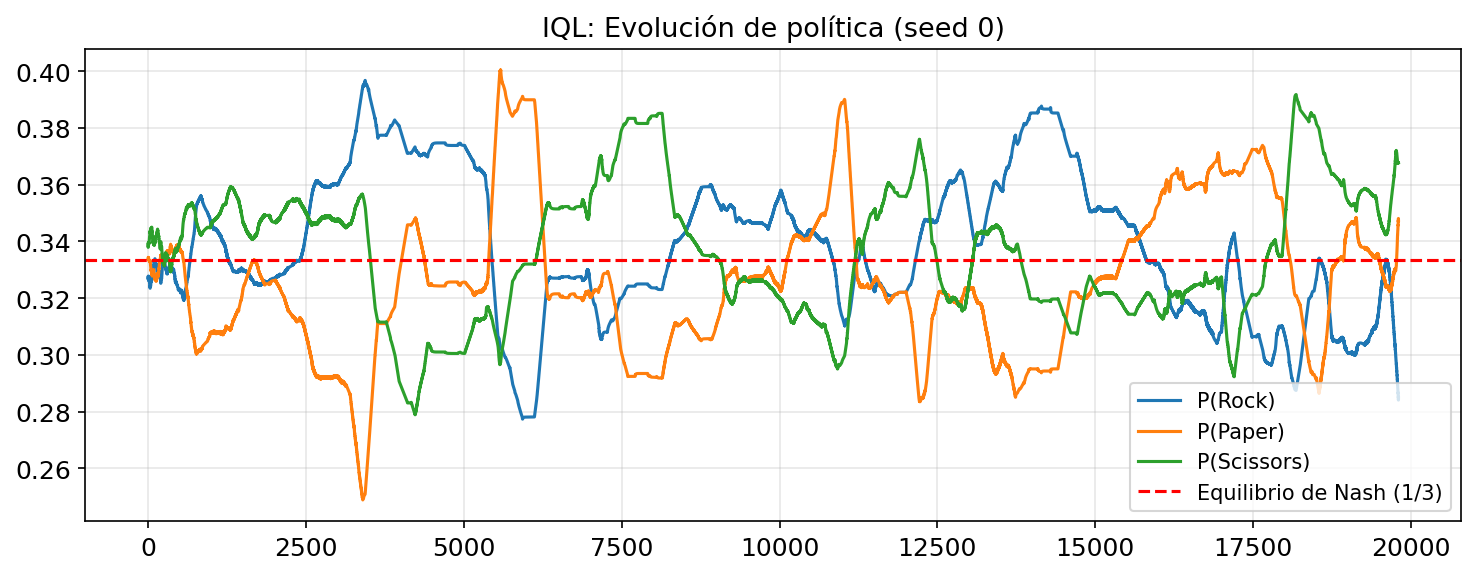

In [29]:
# --- RPS-3: IQL vs IQL ---
rewards_iql, pol0_iql, pol1_iql = run_experiment(
    RPS, IndependentQLearning, IndependentQLearning, N_EPISODES, N_SEEDS,
    agent0_kwargs=iql_kwargs, agent1_kwargs=iql_kwargs)

save_results('RPS', 'IQL_vs_IQL', rewards_iql, pol0_iql, pol1_iql,
             ne=NE_RPS.tolist(), hyperparams=iql_kwargs)

fig, axes = plt.subplots(1, 1, figsize=(10, 4))

# Evolución de las 3 acciones (seed 0)
for i, name in enumerate(['Rock', 'Paper', 'Scissors']):
    axes.plot(smooth(pol0_iql[0, :, i], 200), label=f'P({name})')
axes.axhline(1/3, ls='--', c='red', label='Equilibrio de Nash (1/3)')
axes.set_title('IQL: Evolución de política (seed 0)'); axes.legend()
plt.tight_layout(); plt.savefig('figures/RPS/iql_vs_iql.png', dpi=150); plt.show()

#### SECCIÓN 4 — Experimento JAL-AM vs JAL-AM


Saved → results/RPS/JALAM_vs_JALAM/results.json


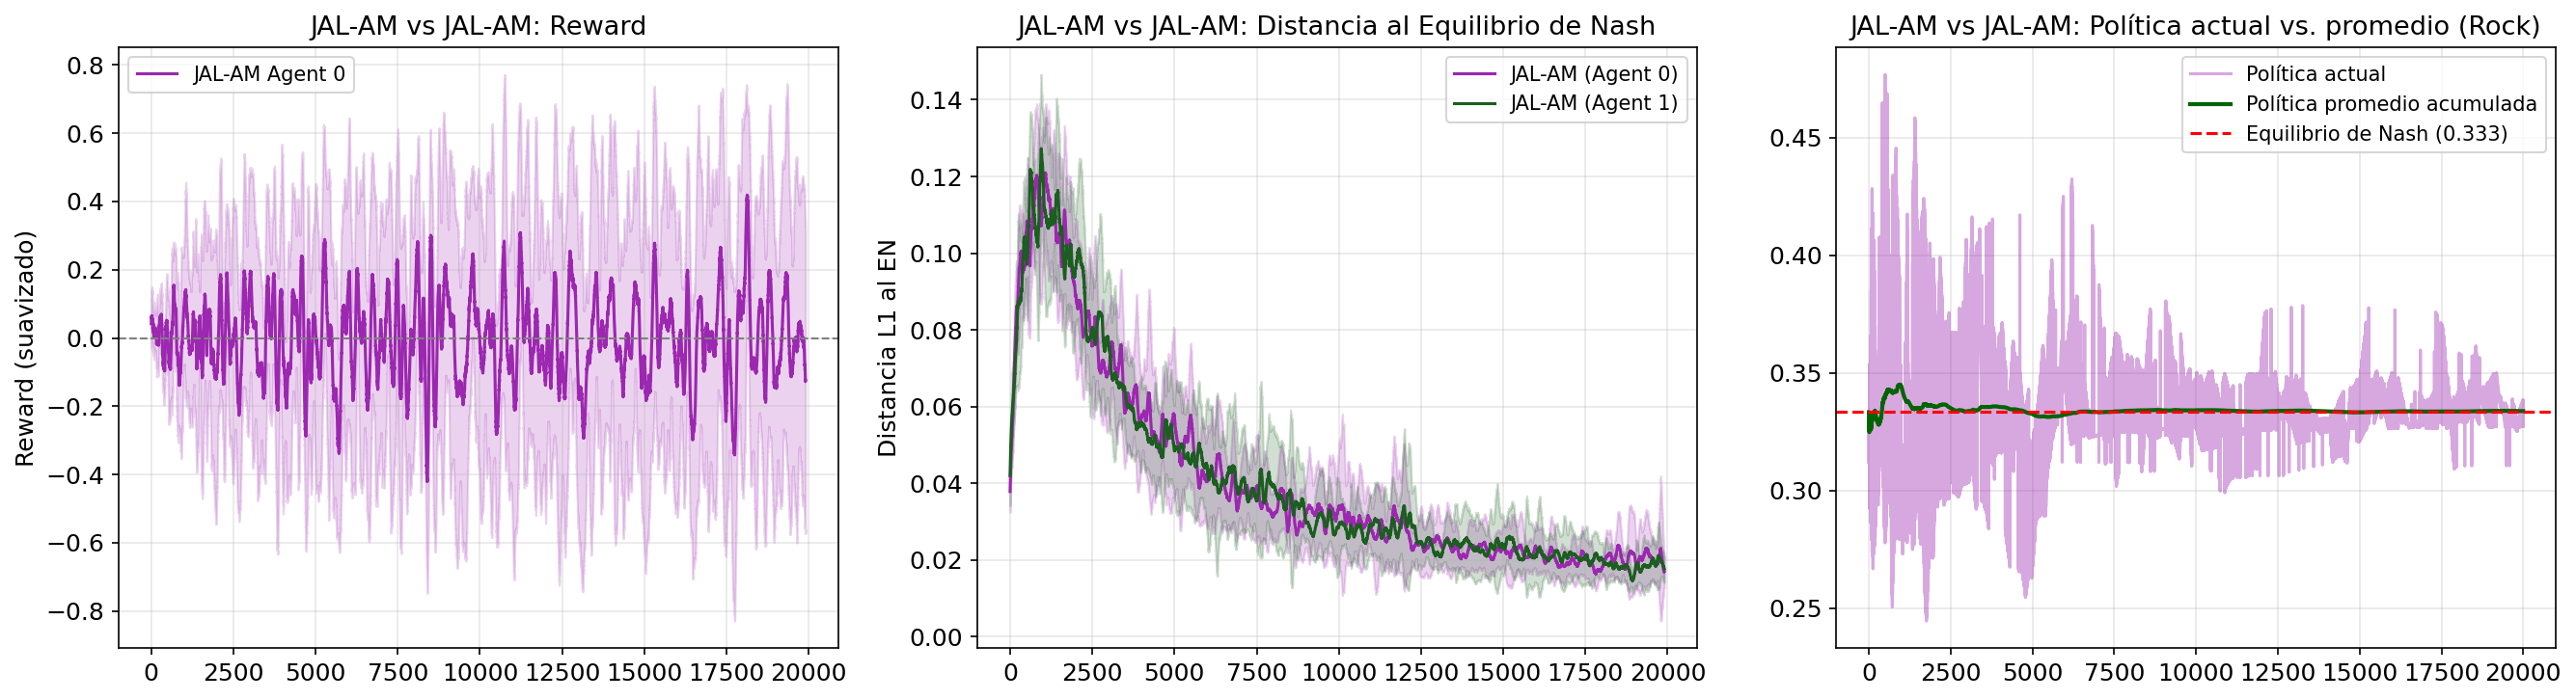

Política final FP (promedio sobre seeds):
  Agent 0: [0.332 0.336 0.332]
  Agent 1: [0.333 0.332 0.335]
  Equilibrio de Nash: [0.333 0.333 0.333]


In [30]:
jalam_kwargs = dict[str, float](alpha=0.1, gamma=0.0, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01)
reward_jal, pol0_jal, pol1_jal = run_experiment_and_plot(
    RPS, JointActionLearningAM, JointActionLearningAM,
    NE=NE_RPS, color=COLORS['JAL-AM'],
    game_name='RPS', experiment_name='JALAM_vs_JALAM',
    agent0_label='JAL-AM', agent1_label='JAL-AM',
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=jalam_kwargs, agent1_kwargs=jalam_kwargs
)

## Observaciones
En general, los resultados obtenidos muestran que JAL-AM presenta un comportamiento más estable y cercano al equilibrio de Nash que IQL en Rock-Paper-Scissors.

Las recompensas de ambos agentes continúan oscilando alrededor de cero durante todo el entrenamiento, algo esperable en un juego zero-sum. Sin embargo, aunque siguen existiendo fluctuaciones en las políticas instantáneas, estas parecen disminuir progresivamente con el tiempo.

Además, la distancia al equilibrio de Nash muestra una tendencia clara de convergencia hacia valores cercanos a cero. A diferencia de IQL, donde las oscilaciones permanecían relativamente constantes, en JAL-AM puede observarse una reducción más estable y sostenida de la distancia al equilibrio.

Por otro lado, la política promedio acumulada converge rápidamente hacia una distribución muy cercana a $1/3$ para cada acción, consistente con el equilibrio mixto esperado en Rock-Paper-Scissors. Incluso las políticas instantáneas parecen estabilizarse gradualmente alrededor de este valor.

En conjunto, los resultados sugieren que JAL-AM logra aproximar el equilibrio de Nash de forma más estable que IQL. Esto probablemente se debe a que el algoritmo incorpora modelado explícito de las acciones del oponente, reduciendo parcialmente los problemas de no estacionariedad presentes en Independent Q-Learning.

#### SECCIÓN 5 — Experimento: FP vs RM


Saved → results/RPS/FP_vs_RM/results.json


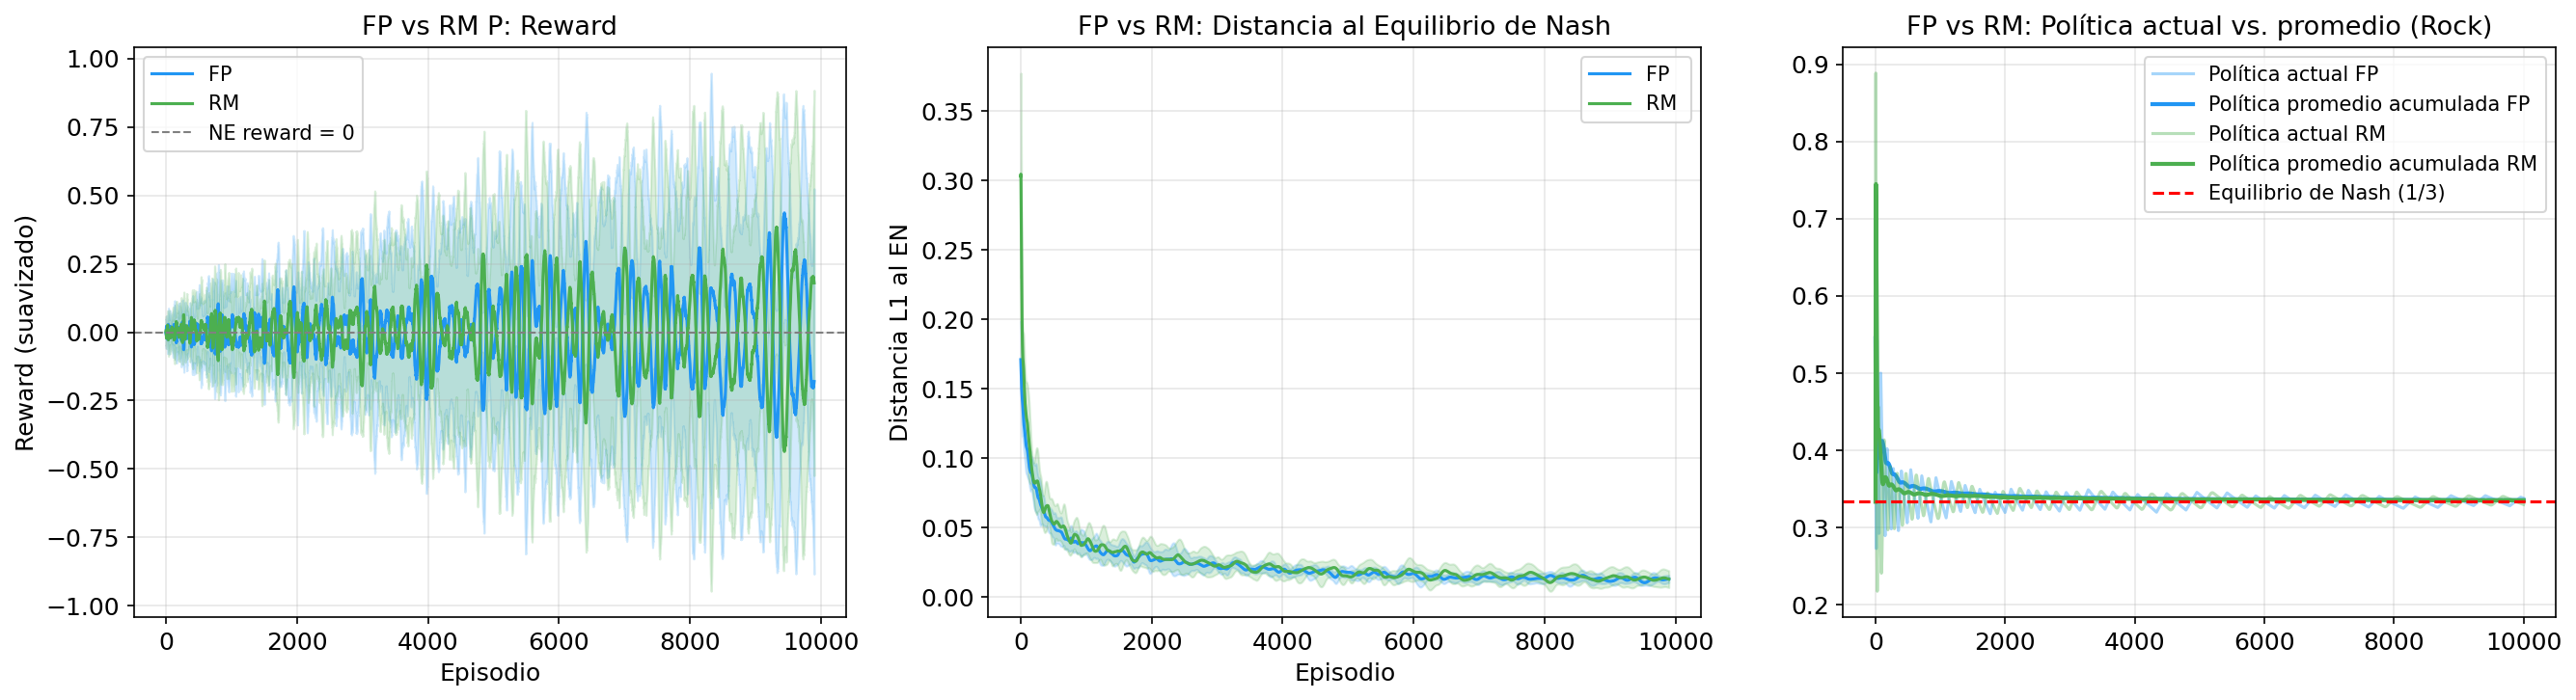

<Figure size 1350x750 with 0 Axes>

Política final (promedio sobre seeds):
  Agent FP: [0.334 0.333 0.333]
  Agent RM: [0.335 0.333 0.332]
  Equilibrio de Nash: [0.333 0.333 0.333]


In [60]:
# Gráfica 1a: Reward promedio
episodes = 10_000
rewards_fp_rm, pol0_fp_rm, pol1_fp_rm = run_experiment(
    RPS, FictitiousPlay, RegretMatching, episodes, N_SEEDS)

save_results('RPS', 'FP_vs_RM', rewards_fp_rm, pol0_fp_rm, pol1_fp_rm,
             ne=NE_RPS.tolist(), hyperparams={'n_episodes': episodes})
remove_first_ep = 0
n_episodes = episodes - remove_first_ep
pol0_fp_rm = pol0_fp_rm[:, remove_first_ep:, :]
pol1_fp_rm = pol1_fp_rm[:, remove_first_ep:, :]



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_with_ci(rewards_fp_rm[:, :, 0], 'FP', COLORS['FP'], ax=axes[0])
plot_with_ci(rewards_fp_rm[:, :, 1], 'RM', COLORS['RM'], ax=axes[0])
axes[0].axhline(0, ls='--', c='gray', lw=1, label='NE reward = 0')
axes[0].set_xlabel('Episodio'); axes[0].set_ylabel('Reward (suavizado)')
axes[0].set_title('FP vs RM P: Reward'); axes[0].legend()

# Gráfica 1b: Distancia al Equilibrio de Nash
d_fp0 = dist_to_ne(pol0_fp_rm, NE_RPS)
d_fp1 = dist_to_ne(pol1_fp_rm, NE_RPS)
plot_with_ci(d_fp0, 'FP', COLORS['FP'], ax=axes[1])
plot_with_ci(d_fp1, 'RM ', COLORS['RM'], ax=axes[1])
axes[1].set_xlabel('Episodio'); axes[1].set_ylabel('Distancia L1 al EN')
axes[1].set_title('FP vs RM: Distancia al Equilibrio de Nash'); axes[1].legend()



# Política actual vs. promedio (seed 0, acción Rock)
pol_curr = pol0_fp_rm[0, :, 0]                     # política actual, acción Rock, seed 0
pol_avg  = np.cumsum(pol0_fp_rm[0, :, 0]) / (np.arange(n_episodes) + 1)  # promedio acumulado
axes[2].plot(pol_curr, alpha=0.4, color=COLORS['FP'], label='Política actual FP')
axes[2].plot(pol_avg,  color=COLORS['FP'], lw=2, label='Política promedio acumulada FP')

pol1_curr = pol1_fp_rm[0, :, 0]                     # política actual, acción Rock, seed 0
pol1_avg  = np.cumsum(pol1_fp_rm[0, :, 0]) / (np.arange(n_episodes) + 1)  # promedio acumulado
axes[2].plot(pol1_curr, alpha=0.4, color=COLORS['RM'], label='Política actual RM')
axes[2].plot(pol1_avg,  color=COLORS['RM'], lw=2, label='Política promedio acumulada RM')

axes[2].axhline(1/3, ls='--', c='red', label='Equilibrio de Nash (1/3)')
axes[2].set_title('FP vs RM: Política actual vs. promedio (Rock)'); axes[2].legend()
plt.tight_layout(); plt.savefig('figures/RPS/fp_vs_rm.png', dpi=150); plt.show()

plt.tight_layout()
plt.savefig('figures/RPS/fp_vs_rm.png', dpi=150)
plt.show()

# Política final
print("Política final (promedio sobre seeds):")
print(f"  Agent FP: {pol0_fp_rm[:, -100:, :].mean(axis=(0,1)).round(3)}")
print(f"  Agent RM: {pol1_fp_rm[:, -100:, :].mean(axis=(0,1)).round(3)}")
print(f"  Equilibrio de Nash: {NE_RPS.round(3)}")

## Observaciones
En general, los resultados obtenidos muestran que tanto Fictitious Play como Regret Matching logran aproximar correctamente el equilibrio de Nash en Rock-Paper-Scissors cuando compiten entre sí.

Las recompensas de ambos agentes oscilaron alrededor de cero durante todo el entrenamiento, comportamiento esperable en un juego zero-sum donde ninguno de los jugadores logra mantener una ventaja permanente sobre el otro. Además, ambos algoritmos presentan oscilaciones similares en las políticas instantáneas, reflejando la adaptación continua frente al comportamiento del oponente.

La distancia al equilibrio de Nash disminuye rápidamente durante los primeros episodios y luego converge hacia valores muy cercanos a cero para ambos agentes. Esto indica que tanto FP como RM aprenden estrategias consistentes con el equilibrio mixto esperado del juego.

Por otro lado, las políticas promedio acumuladas convergen de forma muy estable hacia una distribución cercana a $1/3$ para cada acción. Las políticas finales promedio obtenidas para ambos agentes son prácticamente idénticas al equilibrio de Nash teórico:

$\pi^* = (0.333, 0.333, 0.333)$

Además, puede observarse que RM parece estabilizarse ligeramente más rápido que FP durante las primeras iteraciones, aunque ambos algoritmos terminan convergiendo hacia comportamientos muy similares.

En conjunto, los resultados muestran que FP y RM presentan un desempeño sólido y consistente en Rock-Paper-Scissors, logrando aproximar correctamente el equilibrio mixto esperado y confirmando el comportamiento teórico esperado para ambos algoritmos en juegos simultáneos de suma cero.


#### SECCIÓN 5 — Experimento RPS-5: Todos vs Random


Saved → results/RPS/FP_vs_Random/results.json
Saved → results/RPS/RM_vs_Random/results.json
Saved → results/RPS/IQL_vs_Random/results.json
Saved → results/RPS/JALAM_vs_Random/results.json


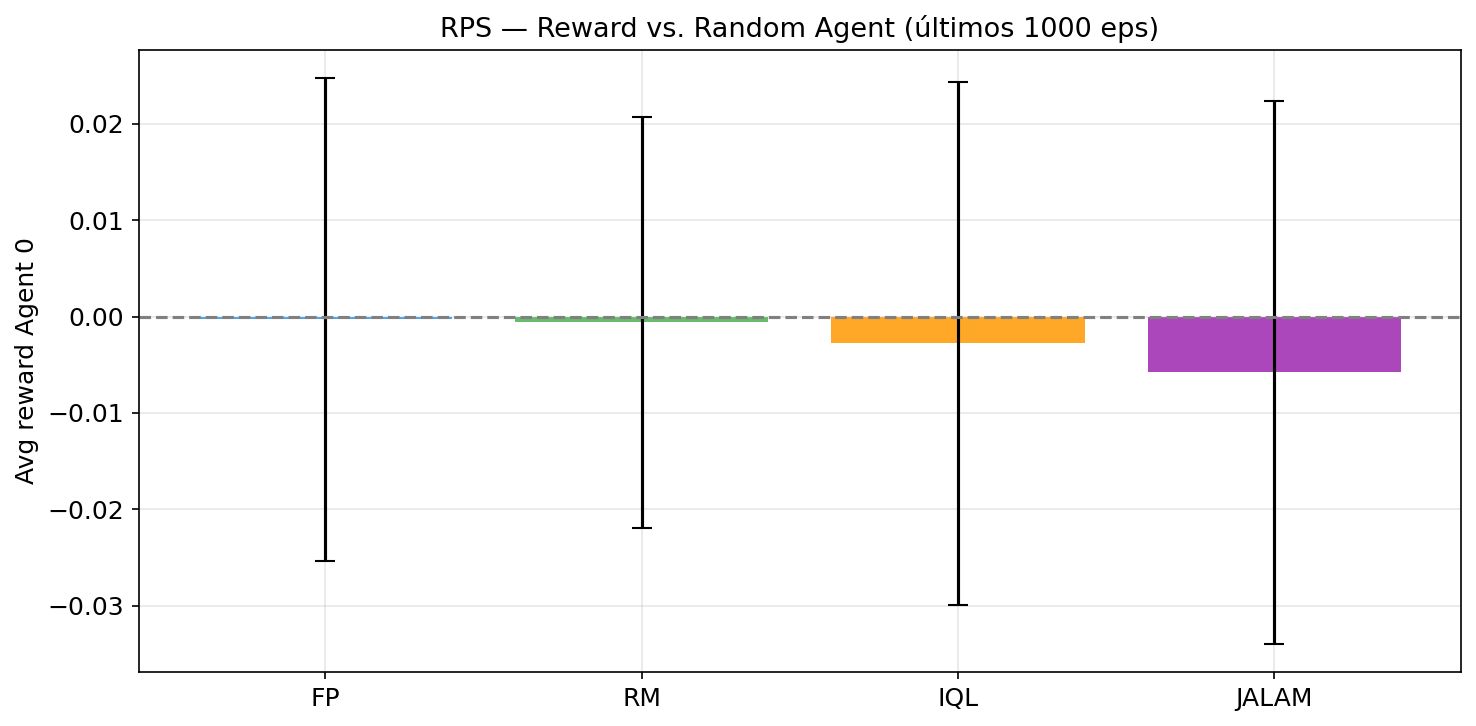

In [31]:
matchups = {
    'FP_vs_Random':    (FictitiousPlay,       RandomAgent,          {}, {}),
    'RM_vs_Random':    (RegretMatching,        RandomAgent,          {}, {}),
    'IQL_vs_Random':   (IndependentQLearning,  RandomAgent, iql_kwargs, {}),
    'JALAM_vs_Random': (JointActionLearningAM, RandomAgent, jalam_kwargs, {}),
}
vs_random_results = {}
for name, (cls0, cls1, kw0, kw1) in matchups.items():
    r, p0, p1 = run_experiment(RPS, cls0, cls1, N_EPISODES, N_SEEDS,
                               agent0_kwargs=kw0, agent1_kwargs=kw1)
    vs_random_results[name] = (r, p0, p1)
    save_results('RPS', name, r, p0, p1)

# Barplot comparativo: avg reward últimos 1000 episodios
fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, (r, _, _)) in enumerate(vs_random_results.items()):
    mean_r = r[:, -1000:, 0].mean()
    std_r  = r[:, -1000:, 0].mean(axis=1).std()
    algo = name.split('_vs_')[0]
    ax.bar(i, mean_r, yerr=std_r, color=COLORS.get(algo, 'gray'),
           capsize=5, label=algo, alpha=0.85)
ax.set_xticks(range(len(matchups))); ax.set_xticklabels([n.split('_vs_')[0] for n in matchups])
ax.set_title('RPS — Reward vs. Random Agent (últimos 1000 eps)'); ax.set_ylabel('Avg reward Agent 0')
ax.axhline(0, ls='--', c='gray'); plt.tight_layout()
plt.savefig('figures/RPS/vs_random_comparison.png', dpi=150); plt.show()

#### SECCIÓN 6 — Experimento RPS-6: Cross-play matrix


In [ ]:
# --- RPS-6: Cross-play (todos vs todos) ---
algo_classes = {
    'FP':     (FictitiousPlay,       {}),
    'RM':     (RegretMatching,        {}),
    'IQL':    (IndependentQLearning,  iql_kwargs),
    'JAL-AM': (JointActionLearningAM, jalam_kwargs),
}
algos = list(algo_classes.keys())
win_rate_matrix = np.zeros((len(algos), len(algos)))
draw_rate_matrix = np.zeros((len(algos), len(algos)))

for i, a0_name in enumerate(algos):
    for j, a1_name in enumerate(algos):
        cls0, kw0 = algo_classes[a0_name]
        cls1, kw1 = algo_classes[a1_name]
        r, _, _ = run_experiment(RPS, cls0, cls1, N_EPISODES, N_SEEDS,
                                 agent0_kwargs=kw0, agent1_kwargs=kw1)
        win_rate_matrix[i, j] = (r[:, :, 0] > 0).mean()
        draw_rate_matrix[i, j] = (r[:, :, 0] == 0).mean()


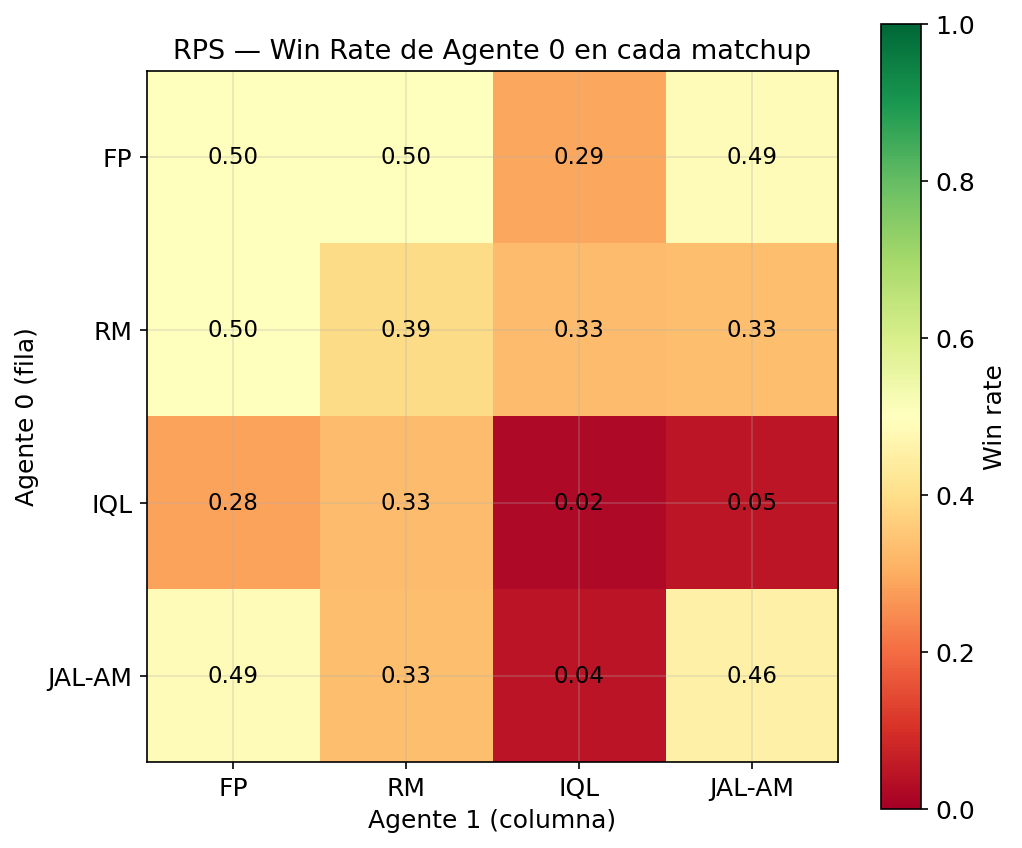

In [57]:
# WIN Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(win_rate_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(algos))); ax.set_yticks(range(len(algos)))
ax.set_xticklabels(algos); ax.set_yticklabels(algos)
ax.set_xlabel('Agente 1 (columna)'); ax.set_ylabel('Agente 0 (fila)')
ax.set_title('RPS — Win Rate de Agente 0 en cada matchup')
plt.colorbar(im, ax=ax, label='Win rate')
for i in range(len(algos)):
    for j in range(len(algos)):
        ax.text(j, i, f'{win_rate_matrix[i,j]:.2f}', ha='center', va='center', fontsize=11)
plt.tight_layout(); plt.savefig('figures/RPS/win_rate_matrix.png', dpi=150); plt.show()

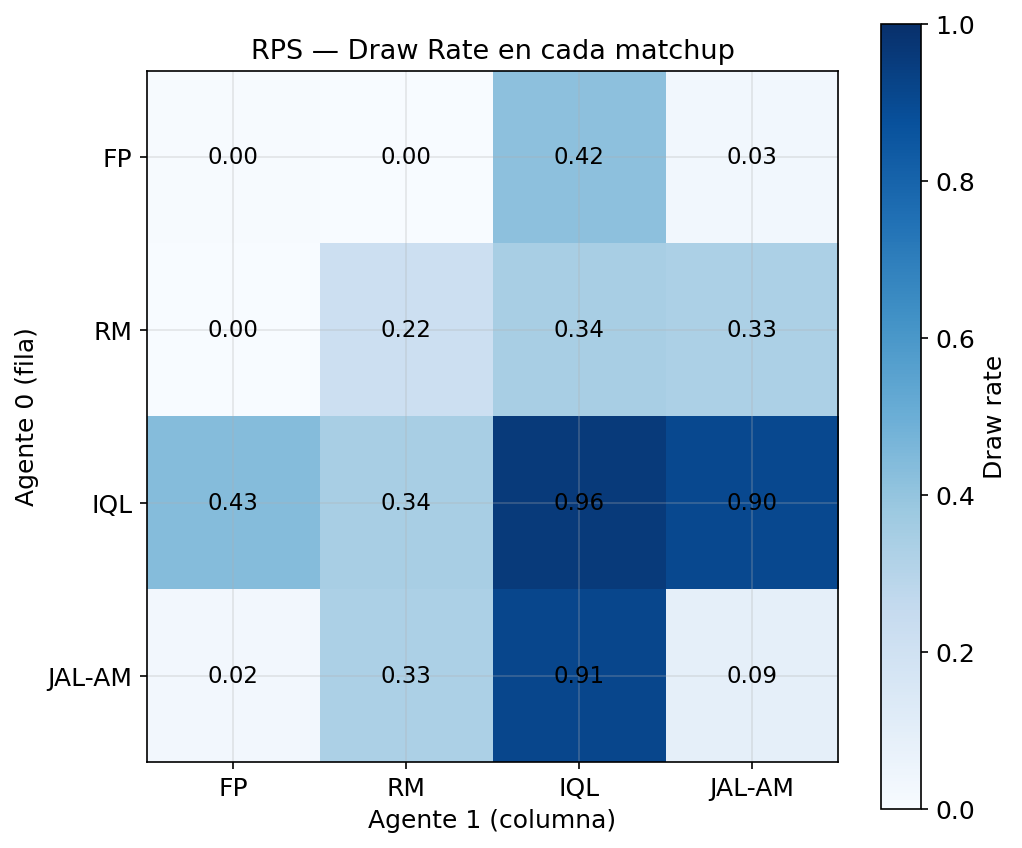

In [58]:
# Heatmap de empates

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(draw_rate_matrix, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(algos)))
ax.set_yticks(range(len(algos)))
ax.set_xticklabels(algos)
ax.set_yticklabels(algos)
ax.set_xlabel('Agente 1 (columna)')
ax.set_ylabel('Agente 0 (fila)')
ax.set_title('RPS — Draw Rate en cada matchup')
plt.colorbar(im, ax=ax, label='Draw rate')
for i in range(len(algos)):
    for j in range(len(algos)):
        ax.text(j, i, f'{draw_rate_matrix[i, j]:.2f}', ha='center', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('figures/RPS/draw_rate_matrix.png', dpi=150)
plt.show()

#### SECCIÓN 7 —  Trajectory Plot en el Simplex (DIFERENCIADOR)


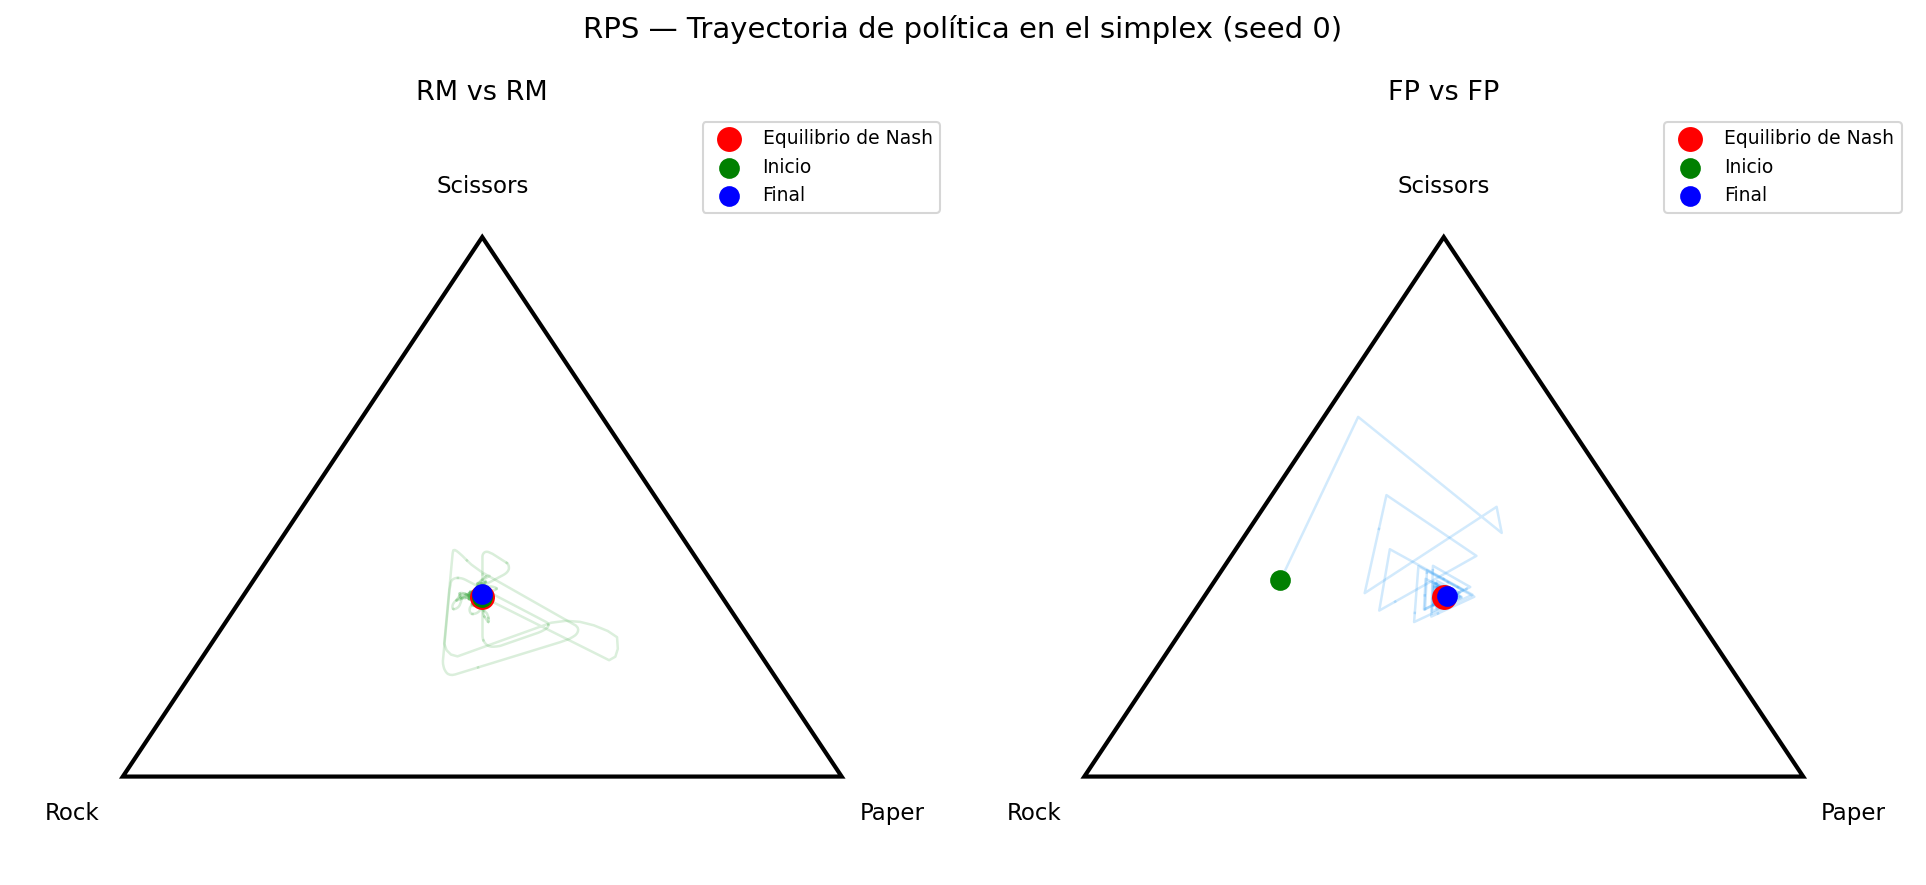

In [35]:
# --- RPS-7: Policy Trajectory en el Simplex ---
def policy_to_simplex(p):
    v = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3)/2]])
    return p @ v

def draw_simplex(ax):
    tri = plt.Polygon([[0,0],[1,0],[0.5,np.sqrt(3)/2]], fill=False, edgecolor='black', lw=2)
    ax.add_patch(tri)
    offset = 0.07
    ax.text(-offset, -offset, 'Rock',     fontsize=11, ha='center')
    ax.text(1+offset, -offset, 'Paper',   fontsize=11, ha='center')
    ax.text(0.5, np.sqrt(3)/2+offset, 'Scissors', fontsize=11, ha='center')
    ne_coord = policy_to_simplex(np.array([1/3,1/3,1/3]))
    ax.scatter(*ne_coord, c='red', s=120, zorder=6, label='Equilibrio de Nash')
    ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.15, np.sqrt(3)/2+0.2)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('RPS — Trayectoria de política en el simplex (seed 0)', fontsize=14)

for ax, pol, name, color in [
    (axes[0], pol0_rm,  'RM',  COLORS['RM']),
    (axes[1], pol0_fp,  'FP',  COLORS['FP']),
]:
    draw_simplex(ax)
    traj = policy_to_simplex(pol[0])  # seed 0, shape (n_episodes, 2)
    # Plotear con gradiente de color para mostrar tiempo
    for k in range(0, len(traj)-1, 50):
        alpha = 0.2 + 0.8 * (k / len(traj))
        ax.plot(traj[k:k+51, 0], traj[k:k+51, 1], color=color, alpha=alpha, lw=1.2)
    ax.scatter(*traj[0],  c='green', s=80, zorder=7, label='Inicio')
    ax.scatter(*traj[-1], c='blue',  s=80, zorder=7, label='Final')
    ax.set_title(f'{name} vs {name}')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout(); plt.savefig('figures/RPS/simplex_trajectory.png', dpi=150); plt.show()

#### SECCIÓN 8 — Comparación final: todos los algoritmos


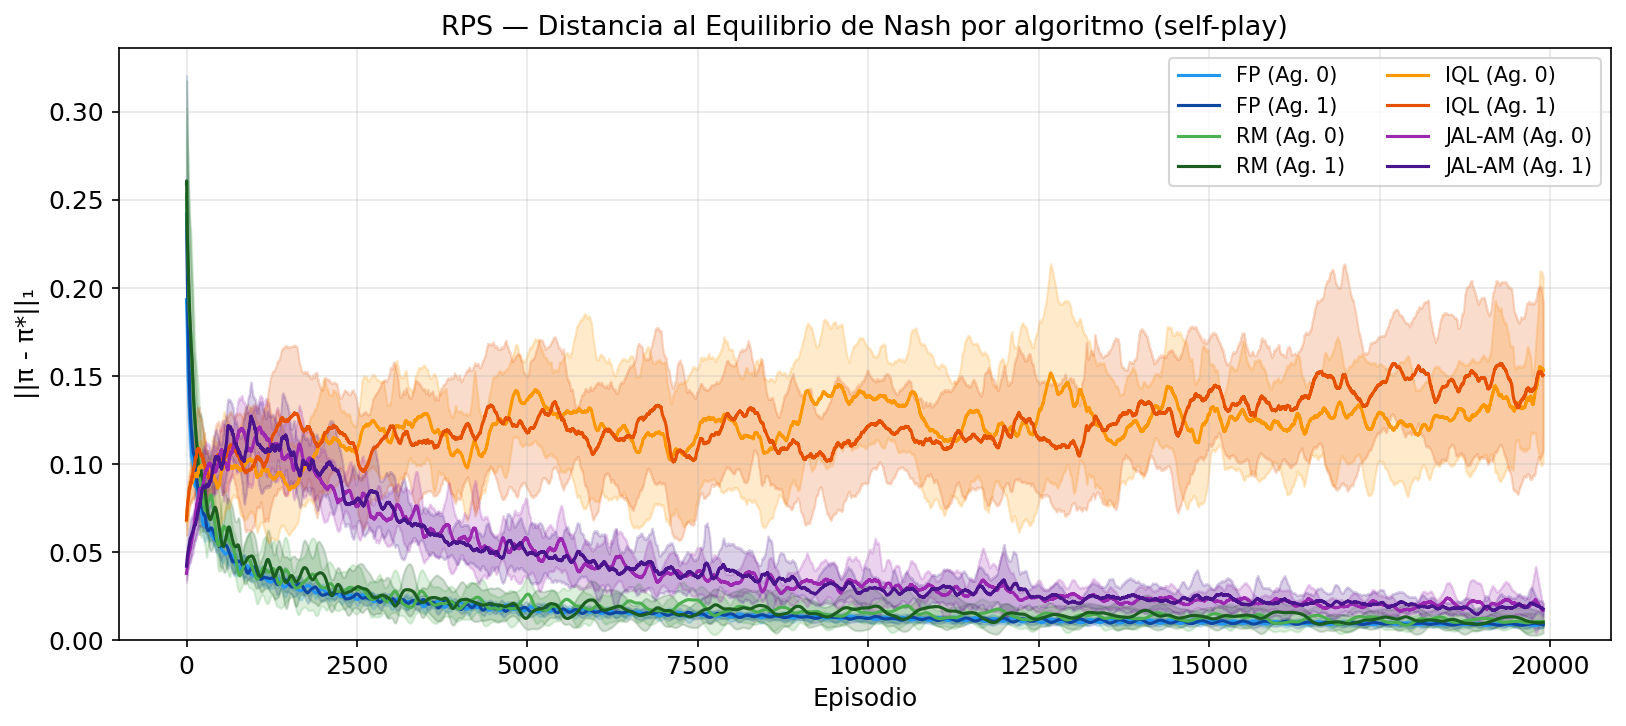


=== TABLA RESUMEN RPS ===
Matchup                       Pol. final A0          Pol. final A1   Dist EN A0   Dist EN A1
-----------------------------------------------------------------------------------------------
FP vs FP                [0.331 0.334 0.335]    [0.335 0.333 0.331]       0.0091       0.0087
RM vs RM                [0.333 0.333 0.334]    [0.333 0.334 0.333]       0.0105       0.0101
IQL vs IQL              [0.328 0.334 0.338]    [0.336 0.328 0.336]       0.1530       0.1505
JAL-AM vs JAL-AM        [0.332 0.336 0.332]    [0.333 0.332 0.335]       0.0169       0.0177


In [36]:
# --- Comparación unificada: distancia al Equilibrio de Nash ---
fig, ax = plt.subplots(figsize=(11, 5))

datasets = [
    (pol0_fp,  pol1_fp,  'FP',     COLORS['FP'],     '#0D47A1'),
    (pol0_rm,  pol1_rm,  'RM',     COLORS['RM'],     '#1B5E20'),
    (pol0_iql, pol1_iql, 'IQL',    COLORS['IQL'],    '#E65100'),
    (pol0_jal, pol1_jal, 'JAL-AM', COLORS['JAL-AM'], '#4A148C'),
]
for pol0, pol1, name, c0, c1 in datasets:
    plot_with_ci(dist_to_ne(pol0, NE_RPS), f'{name} (Ag. 0)', c0, ax=ax)
    plot_with_ci(dist_to_ne(pol1, NE_RPS), f'{name} (Ag. 1)', c1, ax=ax)

ax.set_xlabel('Episodio'); ax.set_ylabel('||\u03c0 - \u03c0*||\u2081')
ax.set_title('RPS — Distancia al Equilibrio de Nash por algoritmo (self-play)')
ax.legend(ncol=2); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.savefig('figures/RPS/all_algos_distance_ne.png', dpi=150); plt.show()

# Tabla resumen
print("\n=== TABLA RESUMEN RPS ===")
print(f"{'Matchup':<20} {'Pol. final A0':>22} {'Pol. final A1':>22} {'Dist EN A0':>12} {'Dist EN A1':>12}")
print("-" * 95)
for pol0, pol1, name, _, _ in datasets:
    pf0 = pol0[:, -100:, :].mean(axis=(0,1))
    pf1 = pol1[:, -100:, :].mean(axis=(0,1))
    d0  = dist_to_ne(pol0, NE_RPS)[:, -100:].mean(axis=1).mean()
    d1  = dist_to_ne(pol1, NE_RPS)[:, -100:].mean(axis=1).mean()
    print(f"{name+' vs '+name:<20} {str(pf0.round(3)):>22} {str(pf1.round(3)):>22} {d0:>12.4f} {d1:>12.4f}")

# Conclusión

En general, los experimentos realizados en Rock-Paper-Scissors muestran comportamientos consistentes con las propiedades teóricas esperadas de cada algoritmo en juegos simultáneos de suma cero.

Los algoritmos basados en teoría de juegos, particularmente Fictitious Play (FP) y Regret Matching (RM), lograron aproximar correctamente el equilibrio de Nash mixto del juego. En ambos casos, las políticas promedio acumuladas convergieron de manera estable hacia una distribución cercana a $(1/3, 1/3, 1/3)$, mientras que las recompensas permanecieron oscilando alrededor de cero, como era esperable en un juego zero-sum.

Además, tanto FP como RM mostraron una reducción progresiva de la distancia al equilibrio de Nash. Sin embargo, RM presentó un comportamiento ligeramente más estable y con oscilaciones menores durante el entrenamiento.

Por otro lado, los algoritmos basados en aprendizaje por refuerzo multiagente presentaron mayores dificultades. Independent Q-Learning (IQL) mostró un comportamiento considerablemente más inestable debido a la no estacionariedad del entorno, ya que cada agente aprende mientras el oponente modifica continuamente su política. Aunque IQL logró aproximarse parcialmente al equilibrio en promedio, las políticas instantáneas mantuvieron oscilaciones importantes y la distancia al equilibrio no convergió de forma clara.

Finalmente, Joint-Action Learning with Agent Modeling (JAL-AM) obtuvo mejores resultados que IQL. Al incorporar modelado explícito sobre las acciones del oponente, JAL-AM logró una convergencia más estable y una aproximación más consistente al equilibrio de Nash. Las oscilaciones observadas fueron menores y las políticas promedio convergieron de forma más precisa hacia la estrategia mixta esperada.

En conjunto, los resultados muestran que los algoritmos basados en teoría de juegos resultan especialmente efectivos en juegos simultáneos estáticos como Rock-Paper-Scissors, mientras que enfoques de aprendizaje por refuerzo multiagente como IQL presentan mayores dificultades debido a la no estacionariedad. Asimismo, incorporar modelado del oponente, como en JAL-AM, permite mejorar significativamente la estabilidad y convergencia del aprendizaje.
